# 01 — Exploratory Data Analysis

Brain tumour MRI dataset: what is in it, how it is distributed, and which
properties drive the preprocessing decisions made in `src/data/preprocessing.py`.

Four classes — `glioma`, `meningioma`, `notumor`, `pituitary` — split into
`Training/` and `Testing/` folders.

In [1]:
import sys
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Make `src` importable when the notebook runs from notebooks/
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.utils.project import CLASS_NAMES, load_config, resolve_raw_dir

%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

config = load_config(str(ROOT / "configs/config.yaml"))
import os
os.chdir(ROOT)                      # resolve_raw_dir uses relative paths
RAW_DIR = resolve_raw_dir(config)

print("dataset root:", RAW_DIR)
print("classes     :", CLASS_NAMES)

dataset root: Dataset
classes     : ['glioma', 'meningioma', 'notumor', 'pituitary']


## 1. Class distribution

The first thing to establish is whether the classes are balanced, because that
decides whether the training scripts need `class_weight`.

In [2]:
IMAGE_SUFFIXES = {".jpg", ".jpeg", ".png"}

def count_images(split):
    return {
        cls: sum(1 for p in (RAW_DIR / split / cls).iterdir()
                 if p.suffix.lower() in IMAGE_SUFFIXES)
        for cls in CLASS_NAMES
    }

counts = pd.DataFrame({s: count_images(s) for s in ["Training", "Testing"]})
counts["Total"] = counts.sum(axis=1)
counts.loc["Total"] = counts.sum()
counts

,Training,Testing,Total
glioma,1400,400,1800
meningioma,1400,400,1800
notumor,1400,400,1800
pituitary,1400,400,1800
Total,5600,1600,7200


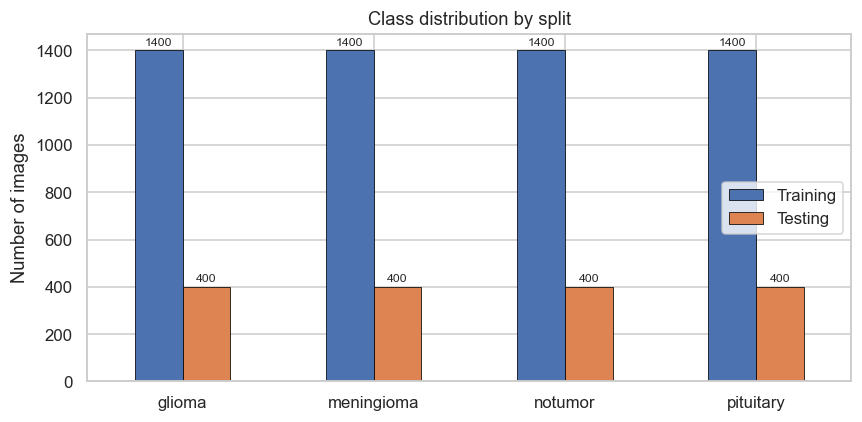

Training imbalance ratio (max/min): 1.00


In [3]:
plot_df = counts.drop(index="Total").drop(columns="Total")

ax = plot_df.plot(kind="bar", figsize=(8, 4), rot=0,
                  color=["#4C72B0", "#DD8452"], edgecolor="black", linewidth=0.5)
ax.set_title("Class distribution by split")
ax.set_ylabel("Number of images")
ax.set_xlabel("")
for container in ax.containers:
    ax.bar_label(container, fontsize=8, padding=2)
plt.tight_layout()
plt.show()

imbalance = plot_df["Training"].max() / plot_df["Training"].min()
print(f"Training imbalance ratio (max/min): {imbalance:.2f}")

**Observation.** This copy of the dataset is exactly balanced — 1400 training and
400 testing images per class, an imbalance ratio of 1.00.

That is worth flagging, because the original Kaggle release
(`masoudnickparvar/brain-tumor-mri-dataset`) is *not* balanced: it ships roughly
1321/1339/1595/1457 training images. This copy has been resampled to be even.

Consequence: `class_weight` in the training scripts computes to ~1.0 for every
class and becomes a no-op. It is kept because it costs nothing and makes the code
correct if the data is ever swapped for the unbalanced original.

For **detection**, though, the binary grouping (`notumor` vs the rest) is
inherently 1:3 — that imbalance is real and `class_weight` does matter there.

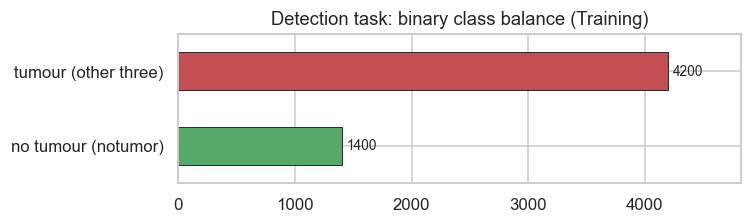

tumour : no-tumour = 3.0 : 1


In [4]:
detection_counts = pd.Series({
    "no tumour (notumor)": counts.loc["notumor", "Training"],
    "tumour (other three)": counts.loc[
        [c for c in CLASS_NAMES if c != "notumor"], "Training"].sum(),
})
ax = detection_counts.plot(kind="barh", figsize=(7, 2.2),
                           color=["#55A868", "#C44E52"], edgecolor="black", linewidth=0.5)
ax.set_title("Detection task: binary class balance (Training)")
ax.bar_label(ax.containers[0], fontsize=9, padding=3)
ax.set_xlim(0, detection_counts.max() * 1.15)
plt.tight_layout()
plt.show()

print(f"tumour : no-tumour = {detection_counts.iloc[1] / detection_counts.iloc[0]:.1f} : 1")

## 2. What the images look like

Three samples per class. Note the variety of acquisition planes — axial, sagittal
and coronal all appear within the same class.

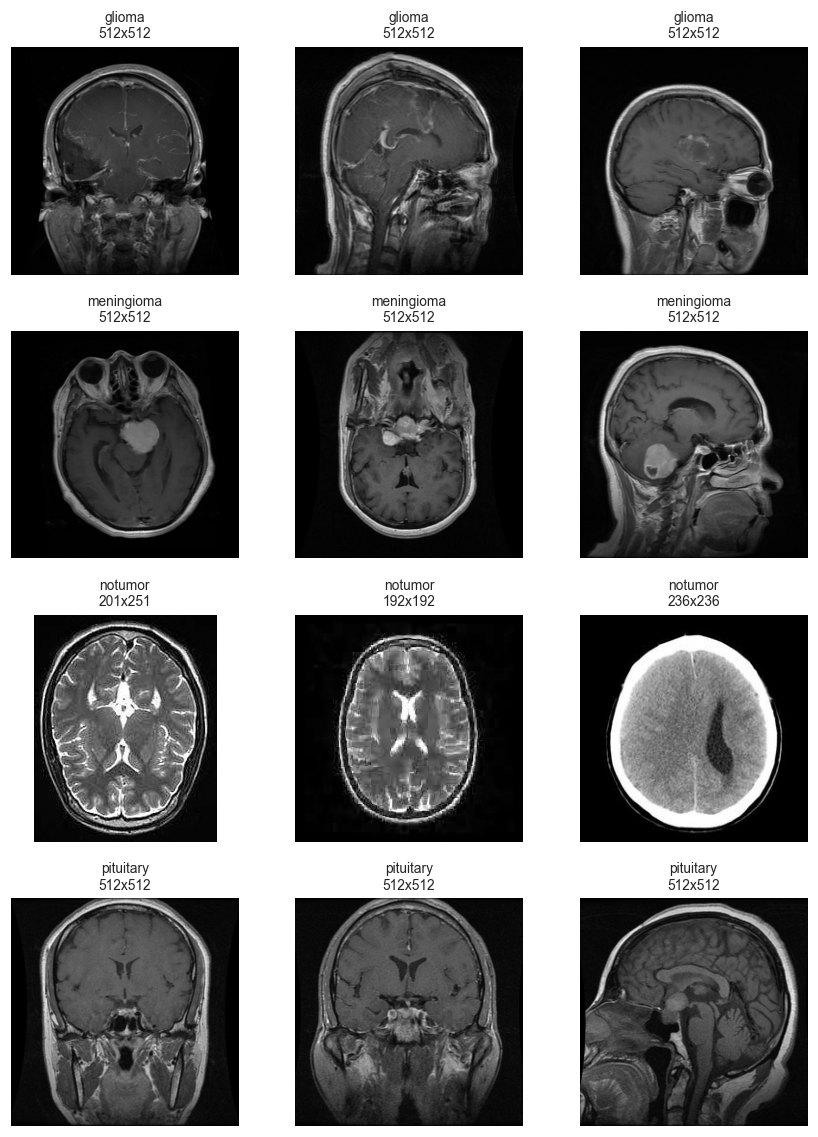

In [5]:
rng = np.random.default_rng(42)
fig, axes = plt.subplots(len(CLASS_NAMES), 3, figsize=(8, 10.5))

for row, cls in enumerate(CLASS_NAMES):
    paths = sorted((RAW_DIR / "Training" / cls).glob("*.jpg"))
    for col, path in enumerate(paths[:3]):
        img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
        axes[row, col].imshow(img, cmap="gray")
        axes[row, col].set_title(f"{cls}\n{img.shape[1]}x{img.shape[0]}", fontsize=9)
        axes[row, col].axis("off")

plt.tight_layout()
plt.show()

## 3. Image dimensions

The models take a fixed 224x224 input, so the spread of native resolutions
determines how much resizing distortion to expect.

Reading every file is slow, so this samples a fixed number per class.

In [6]:
SAMPLE_PER_CLASS = 40

records = []
for cls in CLASS_NAMES:
    paths = sorted((RAW_DIR / "Training" / cls).glob("*.jpg"))
    chosen = rng.choice(len(paths), size=min(SAMPLE_PER_CLASS, len(paths)), replace=False)
    for i in chosen:
        img = cv2.imread(str(paths[i]), cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue
        h, w = img.shape
        records.append(dict(cls=cls, height=h, width=w,
                            aspect=w / h, mean_intensity=float(img.mean()),
                            dark_fraction=float((img < 10).mean())))

sample = pd.DataFrame(records)
print(f"sampled {len(sample)} images ({SAMPLE_PER_CLASS} per class)\n")
sample.groupby("cls")[["height", "width", "aspect"]].agg(["min", "median", "max"])

sampled 160 images (40 per class)



height              width                aspect                   
              min median   max   min median  max       min   median       max
cls                                                                          
glioma        512  512.0   512   512  512.0  512  1.000000  1.00000  1.000000
meningioma    228  512.0   512   221  512.0  512  0.816384  1.00000  1.000000
notumor       192  249.0  1075   173  229.0  890  0.751131  0.99125  1.335052
pituitary     256  512.0   512   256  512.0  512  1.000000  1.00000  1.000000

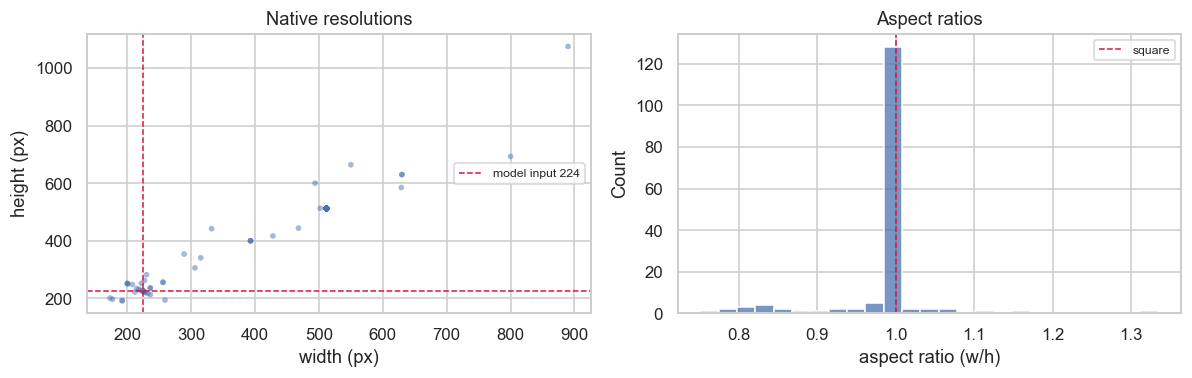

within 2% of square : 82%
resolution range    : 173-890 px wide


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))

axes[0].scatter(sample["width"], sample["height"], s=14, alpha=0.5, edgecolor="none")
axes[0].axvline(224, color="crimson", ls="--", lw=1, label="model input 224")
axes[0].axhline(224, color="crimson", ls="--", lw=1)
axes[0].set_xlabel("width (px)"); axes[0].set_ylabel("height (px)")
axes[0].set_title("Native resolutions"); axes[0].legend(fontsize=8)

sns.histplot(sample["aspect"], bins=25, ax=axes[1], color="#4C72B0")
axes[1].axvline(1.0, color="crimson", ls="--", lw=1, label="square")
axes[1].set_xlabel("aspect ratio (w/h)")
axes[1].set_title("Aspect ratios"); axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

square = (sample["aspect"].between(0.98, 1.02)).mean()
print(f"within 2% of square : {100 * square:.0f}%")
print(f"resolution range    : {sample['width'].min()}-{sample['width'].max()} px wide")

## 4. Intensity distributions

MRI intensity is not calibrated across scanners the way CT Hounsfield units are,
so absolute brightness varies between studies. This is the motivation for CLAHE
(local contrast enhancement) rather than a global intensity normalisation.

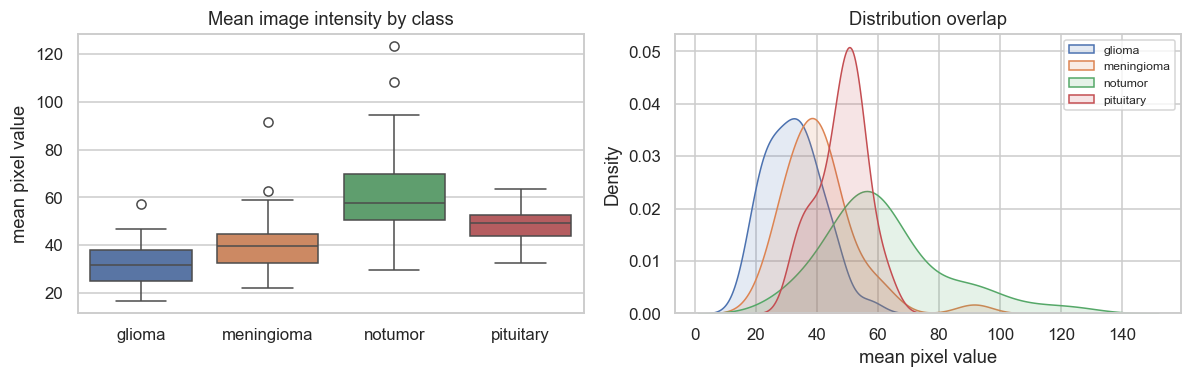

                 mean        std        min         max
cls                                                    
glioma      32.231551   9.136373  16.715122   57.087738
meningioma  40.781190  12.324182  22.057949   91.472147
notumor     62.022401  19.941052  29.718652  123.192004
pituitary   47.998056   7.952368  32.329865   63.599976


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))

sns.boxplot(data=sample, x="cls", y="mean_intensity", ax=axes[0], hue="cls",
            legend=False, palette="deep")
axes[0].set_title("Mean image intensity by class")
axes[0].set_xlabel(""); axes[0].set_ylabel("mean pixel value")

for cls in CLASS_NAMES:
    subset = sample.loc[sample["cls"] == cls, "mean_intensity"]
    sns.kdeplot(subset, ax=axes[1], label=cls, fill=True, alpha=0.15)
axes[1].set_title("Distribution overlap")
axes[1].set_xlabel("mean pixel value"); axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

print(sample.groupby("cls")["mean_intensity"].describe()[["mean", "std", "min", "max"]])

**Observation — and this one matters.** The distributions are *not* interchangeable.
`notumor` averages roughly twice the brightness of `glioma`, and the three tumour
classes sit at clearly different levels.

That is not a biological finding. Brightness reflects the MRI sequence used
(T1, T1-contrast, T2, FLAIR) and the scanner, and the sample grid in section 2
shows the `notumor` folder contains visibly different sequence types from the
tumour folders. So the classes differ partly by *how they were acquired*, not only
by *what is in them*.

Section 3 pointed the same way: `glioma` and `pituitary` are uniformly 512x512,
while `notumor` has a median of 249x229 and stretches to 1075px. Different source,
different acquisition.

If those two signals are strong enough, a model could score well by recognising
the source rather than the pathology. That is worth testing rather than
assuming — section 6 does exactly that.

## 5. Black borders — why the images get cropped

MRI slices are padded with background. Any pixel spent on black border is a pixel
the 224x224 input does not spend on anatomy, so `crop_brain_region()` trims to the
bounding box of the largest foreground contour.

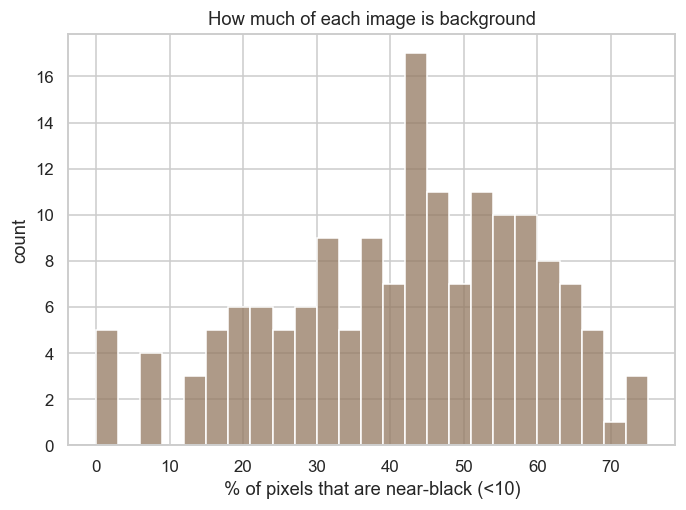

median background fraction : 44%
worst case                 : 75%


In [9]:
sns.histplot(sample["dark_fraction"] * 100, bins=25, color="#937860")
plt.xlabel("% of pixels that are near-black (<10)")
plt.ylabel("count")
plt.title("How much of each image is background")
plt.tight_layout()
plt.show()

print(f"median background fraction : {100 * sample['dark_fraction'].median():.0f}%")
print(f"worst case                 : {100 * sample['dark_fraction'].max():.0f}%")

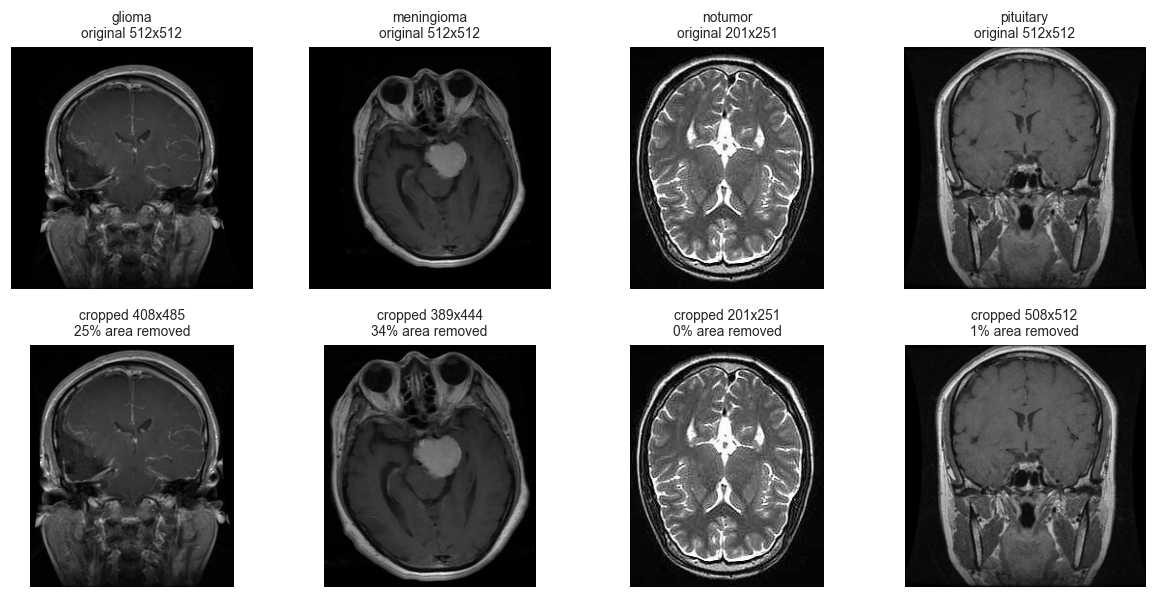

In [10]:
from src.data.preprocessing import crop_brain_region

fig, axes = plt.subplots(2, 4, figsize=(11, 5.6))
for col, cls in enumerate(CLASS_NAMES):
    path = sorted((RAW_DIR / "Training" / cls).glob("*.jpg"))[0]
    img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    cropped = crop_brain_region(img)

    axes[0, col].imshow(img, cmap="gray")
    axes[0, col].set_title(f"{cls}\noriginal {img.shape[1]}x{img.shape[0]}", fontsize=9)
    axes[1, col].imshow(cropped, cmap="gray")
    saved = 100 * (1 - cropped.size / img.size)
    axes[1, col].set_title(f"cropped {cropped.shape[1]}x{cropped.shape[0]}\n{saved:.0f}% area removed",
                           fontsize=9)
    for row in (0, 1):
        axes[row, col].axis("off")

plt.tight_layout()
plt.show()

## 6. Dataset bias check — how much can metadata alone predict?

Sections 3 and 4 suggested the classes differ in resolution and brightness. Here
that suspicion is quantified directly.

A small decision tree is trained on **three numbers per image — width, height and
mean intensity**. It never sees a single pixel of anatomy: no shape, no texture,
no tumour. If it can still separate the classes, then part of the label is
predictable from acquisition characteristics, and a CNN is free to exploit the
same shortcut.

In [11]:
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier

features = sample[["width", "height", "mean_intensity"]]
tree = DecisionTreeClassifier(max_depth=3, random_state=0)

binary_target = (sample["cls"] != "notumor").astype(int)     # tumour vs no tumour
binary_score = cross_val_score(tree, features, binary_target, cv=5).mean()

multi_score = cross_val_score(tree, features, sample["cls"], cv=5).mean()

print("Using ONLY width, height and mean intensity — no pixel content:\n")
print(f"  detection  (tumour vs notumor) : {100 * binary_score:5.1f} %   (chance = 75.0 %)")
print(f"  4-class classification         : {100 * multi_score:5.1f} %   (chance = 25.0 %)")

Using ONLY width, height and mean intensity — no pixel content:

  detection  (tumour vs notumor) :  95.6 %   (chance = 75.0 %)
  4-class classification         :  63.1 %   (chance = 25.0 %)


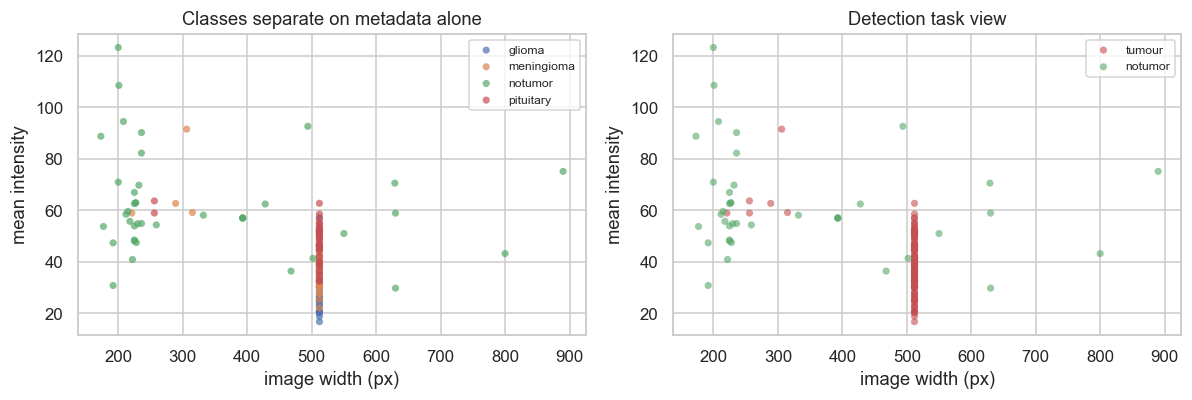

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

palette = dict(zip(CLASS_NAMES, sns.color_palette("deep", len(CLASS_NAMES))))
for cls in CLASS_NAMES:
    subset = sample[sample["cls"] == cls]
    axes[0].scatter(subset["width"], subset["mean_intensity"], label=cls,
                    s=22, alpha=0.7, color=palette[cls], edgecolor="none")
axes[0].set_xlabel("image width (px)")
axes[0].set_ylabel("mean intensity")
axes[0].set_title("Classes separate on metadata alone")
axes[0].legend(fontsize=8)

is_notumor = sample["cls"] == "notumor"
axes[1].scatter(sample.loc[~is_notumor, "width"], sample.loc[~is_notumor, "mean_intensity"],
                label="tumour", s=22, alpha=0.6, color="#C44E52", edgecolor="none")
axes[1].scatter(sample.loc[is_notumor, "width"], sample.loc[is_notumor, "mean_intensity"],
                label="notumor", s=22, alpha=0.6, color="#55A868", edgecolor="none")
axes[1].set_xlabel("image width (px)")
axes[1].set_ylabel("mean intensity")
axes[1].set_title("Detection task view")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

### Does preprocessing remove the shortcut?

The numbers above describe the **raw** files. But the models never see those: every
image is cropped, resized to 224x224 and CLAHE-enhanced first. Resizing destroys
the resolution cue outright, and CLAHE equalises local contrast, which should
suppress much of the brightness cue.

So the question that actually matters is how much of the shortcut *survives
preprocessing*. Re-run the same test on the processed images, where width and
height are constant at 224 and only intensity can carry information.

In [13]:
processed_dir = ROOT / "data" / "processed" / "Training"

if not processed_dir.exists():
    print("data/processed not found - run:")
    print("  python -m src.data.preprocessing --raw-dir Dataset --out-dir data/processed")
else:
    proc_records = []
    for cls in CLASS_NAMES:
        paths = sorted((processed_dir / cls).glob("*.jpg"))
        chosen = rng.choice(len(paths), size=min(SAMPLE_PER_CLASS, len(paths)), replace=False)
        for i in chosen:
            img = cv2.imread(str(paths[i]), cv2.IMREAD_GRAYSCALE)
            if img is None:
                continue
            proc_records.append(dict(cls=cls, mean_intensity=float(img.mean()),
                                     std_intensity=float(img.std())))

    processed = pd.DataFrame(proc_records)
    proc_features = processed[["mean_intensity", "std_intensity"]]

    proc_binary = cross_val_score(
        tree, proc_features, (processed["cls"] != "notumor").astype(int), cv=5).mean()
    proc_multi = cross_val_score(tree, proc_features, processed["cls"], cv=5).mean()

    print(f"sampled {len(processed)} processed images "
          f"(all 224x224, so only intensity can leak)\n")
    print(f"{'':32s} {'raw':>8s}   {'processed':>10s}")
    print(f"{'detection (tumour vs notumor)':32s} {100 * binary_score:7.1f}%   "
          f"{100 * proc_binary:9.1f}%     (chance 75.0%)")
    print(f"{'4-class classification':32s} {100 * multi_score:7.1f}%   "
          f"{100 * proc_multi:9.1f}%     (chance 25.0%)")

sampled 160 processed images (all 224x224, so only intensity can leak)

                                      raw    processed
detection (tumour vs notumor)       95.6%        81.9%     (chance 75.0%)
4-class classification              63.1%        50.6%     (chance 25.0%)


**These two tables are the most important result in this notebook.**

A depth-3 decision tree, given nothing but image width, height and average
brightness, reaches **95.6%** on the detection task against a 75% chance baseline.
It cannot be detecting tumours — it has never seen anatomy. It is recognising
*which source a file came from*.

Preprocessing removes most of that shortcut. Once images are cropped, resized to
224x224 and CLAHE-enhanced, the same test drops to **81.9%**. Resizing destroys the
resolution cue completely, and CLAHE flattens much of the brightness difference.

But it does not remove it entirely. 81.9% against a 75% baseline means intensity
statistics alone still carry real signal in exactly the data the model trains on,
and 50.6% on the 4-class task is still double chance.

What this means for the write-up:

- **The trained accuracies are somewhat optimistic.** Part of the performance
  comes from acquisition characteristics that would not transfer to a new scanner
  or hospital.
- **Say so explicitly.** This is a property of the dataset, not a bug in the
  model, and identifying it is worth more than quoting a high number uncritically.
- **Credit the preprocessing.** Cropping, resizing and CLAHE were chosen for image
  quality, and they measurably cut the leak from 95.6% to 81.9% as a side effect.
- **Do not claim clinical generalisation.** These numbers describe this dataset.
- **The honest stronger test**, if time allows: evaluate on an external dataset
  such as the figshare collection. Cross-source accuracy is the real measure.

## Key findings

1. **Balanced classes** — 1400 train / 400 test per class. `class_weight` is
   effectively a no-op for the 4-class task, but the **detection** task is
   genuinely 3:1 (tumour vs no-tumour) and does need it.
2. **Mixed acquisition planes** — axial, sagittal and coronal slices sit inside
   the same class folder. The model has to be invariant to orientation, which
   justifies the flip and rotation augmentations in `src/data/tf_dataset.py`.
3. **Resolution is class-dependent** — `glioma` and `pituitary` are uniformly
   512x512, while `notumor` has a median of 249x229 and ranges up to 1075px.
4. **Intensity is class-dependent** — `notumor` averages roughly twice the
   brightness of `glioma`, reflecting different MRI sequences rather than biology.
5. **Findings 3 and 4 combine into a dataset confound** (section 6): a decision
   tree using only width, height and mean intensity — no pixel content at all —
   reaches 95.6% on detection against a 75% baseline. Preprocessing cuts this to
   81.9%, so most of the shortcut is removed but some survives. Reported
   accuracies are therefore somewhat optimistic, and the write-up should say so.
6. **Substantial black border** on many slices, motivating `crop_brain_region()`.

Preprocessing consequences, all implemented in `src/data/preprocessing.py`:
crop to the brain, resize to 224 (which removes the raw-resolution cue), and
apply CLAHE for local contrast (which suppresses part of the brightness cue).

The intensity overlap between the three *tumour* classes also explains why
localising a tumour by thresholding is hard — notebook 02 shows that attempt and
where it fails.